# 🕵️ Análise de Fraude e Detecção de Anomalias

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Leitura do dataset
df_path = Path.cwd().parent / "Data" / "PROCESSED" / "leads_processados_para_pbi.csv"
df = pd.read_csv(df_path, parse_dates=['data_cadastro'])
df.head()


,lead_id,origem,data_cadastro,status_conversao,dias_ate_1o_trade,valor_deposito,perfil,pais,foi_convertido,ano_mes_cadastro
0,2001,Orgânico,2025-03-29,Não Convertido,NaN,0.00,NaN,Brasil,False,2025-03
1,2002,Instagram,2025-03-10,Não Convertido,NaN,0.00,NaN,Portugal,False,2025-03
2,2003,Orgânico,2025-02-20,Convertido,6.0,7985.78,Scalper,Espanha,True,2025-02
3,2004,Facebook,2025-03-13,Convertido,7.0,6026.72,Investidor,Brasil,True,2025-03
4,2005,Orgânico,2025-01-28,Convertido,6.0,4513.74,Investidor,Espanha,True,2025-01


## 🧹 Preparação de Dados

In [2]:
# Preenchimento de nulos
df['dias_ate_1o_trade'] = df['dias_ate_1o_trade'].fillna(0)
df['valor_deposito'] = df['valor_deposito'].fillna(0)

# Foco nos leads convertidos
df_convertidos = df[df['status_conversao'] == 'Convertido'].copy()

# Seleção de features numéricas para análise
features = ['dias_ate_1o_trade', 'valor_deposito']
X = df_convertidos[features]

# Normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 🚨 Detecção de Outliers com Isolation Forest

In [3]:
# Modelo
iso = IsolationForest(contamination=0.05, random_state=42)
df_convertidos['anomalia'] = iso.fit_predict(X_scaled)

# -1 é anomalia
outliers = df_convertidos[df_convertidos['anomalia'] == -1]
print(f"Total de outliers detectados: {len(outliers)}")
outliers[['origem', 'pais', 'dias_ate_1o_trade', 'valor_deposito']].head()


Total de outliers detectados: 10


,origem,pais,dias_ate_1o_trade,valor_deposito
18,YouTube Ads,Portugal,9.0,5295.09
61,Indicação,Portugal,0.0,254.80
130,Orgânico,Espanha,0.0,9768.49
135,Orgânico,Portugal,0.0,6380.08
138,Facebook,Argentina,9.0,9857.94


## 📊 Visualização dos Outliers

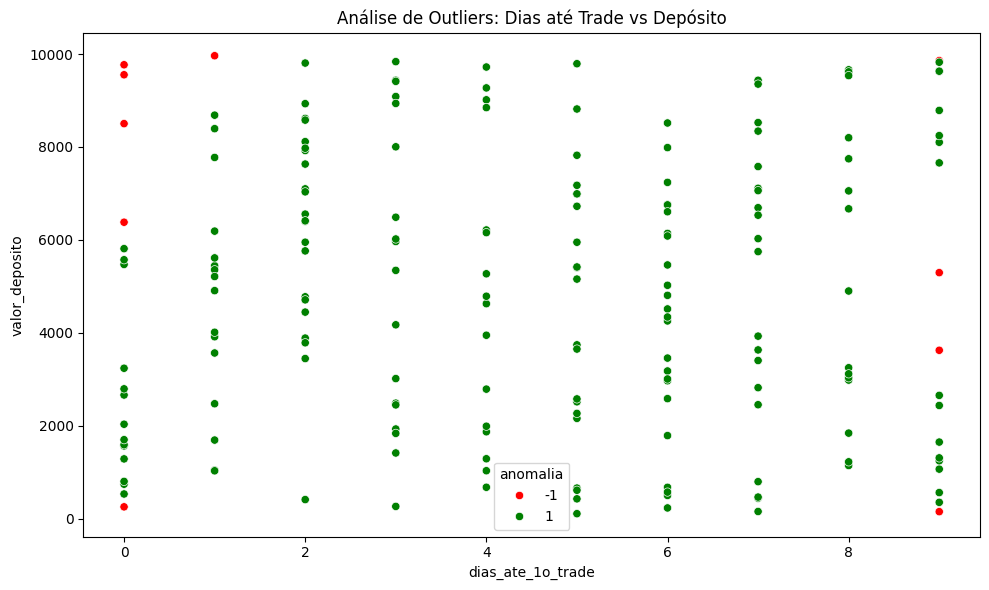

In [4]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_convertidos, x='dias_ate_1o_trade', y='valor_deposito', hue='anomalia', palette={1: 'green', -1: 'red'})
plt.title('Análise de Outliers: Dias até Trade vs Depósito')
plt.tight_layout()
plt.show()


## 🧪 Padrões Suspeitos: Ganhos Altos com Depósitos Baixos

In [5]:
suspeitos = df_convertidos[(df_convertidos['valor_deposito'] < 300) & (df_convertidos['dias_ate_1o_trade'] < 1)]
print(f"Leads com depósito muito baixo e trade imediato: {len(suspeitos)}")
suspeitos[['lead_id', 'origem', 'pais', 'valor_deposito', 'dias_ate_1o_trade']]


Leads com depósito muito baixo e trade imediato: 1


,lead_id,origem,pais,valor_deposito,dias_ate_1o_trade
61,2062,Indicação,Portugal,254.8,0.0
